## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [1]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report


# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
from sklearn.metrics import log_loss
import pandas as pd
import gdown

Using mps device

In [2]:
'''
data_dir = "../models/demo_files 2/NoAdapt/NOvA"
for fn in os.listdir(data_dir):
    print(fn)
'''
#file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"




path_NoAd_T2K= Path("../models/demo_files 2/NoAdapt/T2K")
path_NoAd_Nova= Path('../models/demo_files 2/NoAdapt/NOvA')
path_Ad_T2K= Path('../models/demo_files 2/Adapt/T2K')
path_Ad_Nova= Path('../models/demo_files 2/Adapt/NOvA')

NAD_T2K=[f"{path_NoAd_T2K}/{x}" for x in os.listdir(path_NoAd_T2K)] 
NAD_Nova=[f'{path_NoAd_Nova}/{y}' for y in os.listdir(path_NoAd_Nova)]
AD_T2K=[f'{path_Ad_T2K}/{z}' for z in os.listdir(path_Ad_T2K)]
AD_Nova=[f'{path_Ad_Nova}/{a}' for a in os.listdir(path_Ad_Nova)]

print(NAD_T2K)
print(NAD_Nova)
print(AD_T2K)
print(AD_Nova)




fitting_label = "ID"
paths = [NAD_T2K, NAD_Nova, AD_T2K, AD_Nova]
# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]: Handler List : Hlist

TEMP_NAD_T2K_list = []
TEMP_NAD_Nova_list = []
TEMP_AD_T2K_list = []
TEMP_AD_Nova_list = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
        # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
        #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
        # chain_handler.add_additional_plots(fitting_label, True)

        # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

        # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == NAD_T2K:
            TEMP_NAD_T2K_list.append(chain_handler)
        elif lm == NAD_Nova:
            TEMP_NAD_Nova_list.append(chain_handler)
        elif lm == AD_T2K:
            TEMP_AD_T2K_list.append(chain_handler)
        elif lm == AD_Nova:
            TEMP_AD_Nova_list.append(chain_handler)


NAD_T2K_data = TEMP_NAD_T2K_list[0]
NAD_T2K_data.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

NAD_Nova_data = TEMP_NAD_Nova_list[0]
NAD_Nova_data.ttree_array['ID']= 0

AD_T2K_data = TEMP_AD_T2K_list[0]
AD_T2K_data.ttree_array['ID']= 0

AD_Nova_data = TEMP_AD_Nova_list[0]
AD_Nova_data.ttree_array['ID']= 0


for id, chain in enumerate(TEMP_NAD_T2K_list[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    #chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))*1.2#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
    NAD_T2K_data.ttree_array = pd.concat([NAD_T2K_data.ttree_array, chain.ttree_array])

for ida, chains in enumerate(TEMP_NAD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))*1.2
    NAD_Nova_data.ttree_array = pd.concat([NAD_Nova_data.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(TEMP_AD_T2K_list[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    #chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))*1.2
    AD_T2K_data.ttree_array = pd.concat([AD_T2K_data.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(TEMP_AD_Nova_list[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    #chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))*1.2
    AD_Nova_data.ttree_array = pd.concat([AD_Nova_data.ttree_array, chainsss.ttree_array])

#from now on, the files that include out data that uis now usable are: NAD_T2K_data, NAD_Nova_data, AD_T2K_data, AD_Nova_data

print(NAD_T2K_data.ttree_array)

['../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_all_fixed.root']
['../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/NoAdapt/NOvA/mcmc_NoAdapt_NOvA_all_on.root']
['../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_fixed.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_all_on.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_no_only.root', '../models/demo_files 2/Adapt/T2K/mcmc_Adapt_T2K_oct_fix_mo_fix.root']
['../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_mo_fix.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_oct_fix_no_only.root', '../models/demo_files 2/Adapt/NOvA/mcmc_Adapt_NOvA_all_on.root']
Attempting to open ../models/demo_files 2/NoAdapt/T2K/mcmc_NoAdapt_T2K_oct_fix_no_only.root
Succesfully opened ../models/demo_files 2/NoAdapt/

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [3]:
'''
print(NAD_T2K_data.ttree_array['ID'])

hist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==0].hist()
plt.show()
hist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==1] 

NAD_T2K_data.ttree_array.columns
'''

"\nprint(NAD_T2K_data.ttree_array['ID'])\n\nhist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==0].hist()\nplt.show()\nhist = NAD_T2K_data.ttree_array['delta_cp'][NAD_T2K_data.ttree_array['ID']==1] \n\nNAD_T2K_data.ttree_array.columns\n"

In [4]:
# First step we need to initialise the factory
from pathlib import Path

path_NoAd_T2K.parent.mkdir(parents=True, exist_ok=True)# Make sure the model output directory exists
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory_NADT2K = MLFactory(NAD_T2K_data, fitting_label, f"{path_NoAd_T2K}.pdf")


path_NoAd_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_NADNova = MLFactory(NAD_Nova_data, fitting_label, f"{path_NoAd_Nova}.pdf")



path_Ad_T2K.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADT2K = MLFactory(AD_T2K_data, fitting_label, f"{path_Ad_T2K}.pdf")


path_Ad_Nova.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
ml_factory_ADNova = MLFactory(AD_Nova_data, fitting_label, f"{path_Ad_Nova}.pdf")



ID
ID
ID
ID


Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [5]:
# Now we can make the model/ make the interface on which the model can train and test
from sklearn.metrics import log_loss


#ml_model_NADT2K = ml_factory_NADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30, early_stopping=True, n_iter_no_change= 10)
#ml_model_NADT2K.set_training_test_set(0.5)


ml_model_NADNova = ml_factory_NADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=50, verbose=2, max_leaf_nodes=30)
ml_model_NADNova.set_training_test_set(0.3)
'''
ml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model_ADT2K.set_training_test_set(0.3)

ml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model_ADNova.set_training_test_set(0.3)
'''

"\nml_model_ADT2K = ml_factory_ADT2K.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model_ADT2K.set_training_test_set(0.3)\n\nml_model_ADNova = ml_factory_ADNova.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model_ADNova.set_training_test_set(0.3)\n"

Training Model
Binning 0.627 GB of training data: 1.077 s
Binning 0.070 GB of validation data: 0.113 s
Fitting gradient boosted rounds:
[1/50] 3 trees, 90 leaves (30 on avg), max depth = 11, train loss: 0.93676, val loss: 0.93711, in 0.543s
[2/50] 3 trees, 90 leaves (30 on avg), max depth = 12, train loss: 0.82054, val loss: 0.82122, in 0.522s
[3/50] 3 trees, 90 leaves (30 on avg), max depth = 12, train loss: 0.73301, val loss: 0.73391, in 0.519s
[4/50] 3 trees, 90 leaves (30 on avg), max depth = 12, train loss: 0.66428, val loss: 0.66527, in 0.551s
[5/50] 3 trees, 90 leaves (30 on avg), max depth = 15, train loss: 0.60949, val loss: 0.61062, in 0.566s
[6/50] 3 trees, 90 leaves (30 on avg), max depth = 13, train loss: 0.56519, val loss: 0.56643, in 0.880s
[7/50] 3 trees, 90 leaves (30 on avg), max depth = 12, train loss: 0.52786, val loss: 0.52908, in 0.781s
[8/50] 3 trees, 90 leaves (30 on avg), max depth = 14, train loss: 0.49568, val loss: 0.49696, in 0.598s
[9/50] 3 trees, 90 leave

Number of independent MCMCs: 3

Training Results!

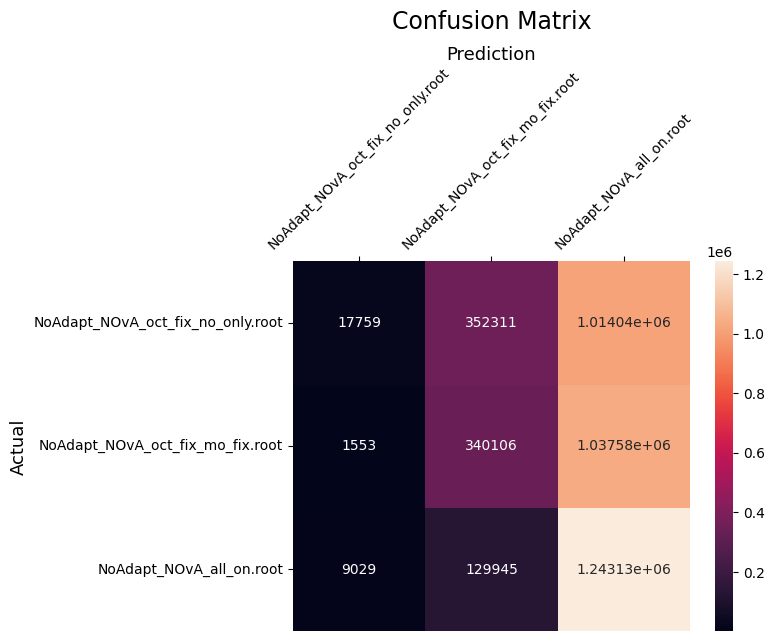

[[  17759  352311 1014038]
 [   1553  340106 1037576]
 [   9029  129945 1243132]]

predictive accuracy: 0.38620593330179676

R*: 1.1586177999053904

=====

Testing Results!

train prediction:[2 1 2 ... 2 2 2]

train true:         ID
1633855   2
1416189   1
1391299   0
1596225   1
1468127   2
...      ..
1280176   1
27924     2
134787    0
39740     2
1496093   2

[4145449 rows x 1 columns]

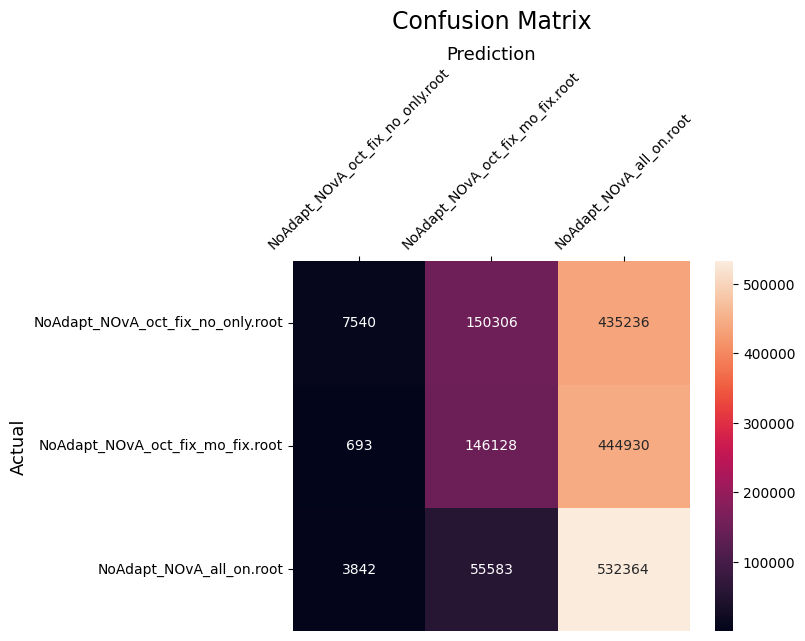

[[  7540 150306 435236]
 [   693 146128 444930]
 [  3842  55583 532364]]

predictive accuracy: 0.38614404189523716

R*: 1.1584321256857115

=====

test prediction:[2 2 2 ... 1 2 1]

test true:         ID
665286    0
1714074   0
1141569   1
1138829   2
1227048   2
...      ..
639946    0
349677    1
883546    1
864950    2
794481    1

[1776622 rows x 1 columns]

ValueError: X has 1 features, but HistGradientBoostingClassifier is expecting 21 features as input.

In [ ]:

# Now we need to train our network
#ml_model_NADT2K.train_model()

#scikitmodel_NADT2K= ml_model_NADT2K.model
scikitmodel_NADNova= ml_model_NADNova.model

ml_model_NADNova.train_model()


#ml_model_NADT2K.test_model_class(NAD_T2K)
ml_model_NADNova.test_model_class(NAD_Nova)

train_loss = scikitmodel_NADNova.train_score_
train_loss_list = train_loss.tolist()

print(train_loss_list)

train_loss_list = [abs(x) for x in train_loss_list]# abs val

x_vals= list(range(1,len(train_loss_list)+1 ))

w, h = 12, 8             
margin = 2

# create a 1×2 grid of axes
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(w, h),
                         facecolor='lightblue')

fig.subplots_adjust(
    left=margin/w,         # space on left
    right=1 - margin/w,    # space on right
    bottom=margin/h,       # space on bottom
    top=1 - margin/h,      # space on top
    wspace=margin/h        # horizontal gap between plots
)

# now you can plot into each axis:
axes[0].plot(x_vals, train_loss_list)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

axes[1].loglog(x_vals, train_loss_list)
axes[1].set_title('Log - Training Loss')
axes[1].set_xlabel('Epochs - Log')
axes[1].set_ylabel('Loss - Log')
plt.show()

LearningCurveDisplay.from_estimator( #prints out how well model learns when you give it a training size of 50, 80, 110 etx
   scikitmodel_NADNova, ml_model_NADNova._training_data, ml_model_NADNova._training_labels, train_sizes=[50, 80, 110], cv=2) 


#ml_model_NADNova.train_model()

#ml_model_ADT2K.train_model()

#ml_model_ADNova.train_model()


In [ ]:


#list = ml_model_NADT2K.test_model_class(NAD_T2K)



# code below is to plot the different values of R*
#maybe make the process in this block a Class??
#datapoints = 3
'''
ml_model_NADNova.test_model_class(NAD_Nova)
list_2 = ml_model_NADNova.getRStar_vals(NAD_Nova)# gets an array of R* values for chain list 2 (chain list 2 has 2 separate .ROOT files, chain 4 has 4 etc...)

ml_model_ADT2K.test_model_class(AD_T2K)
list_4 = ml_model_ADT2K.getRStar_vals(AD_T2K)

ml_model_ADNova.test_model_class(AD_Nova)
list_8 = ml_model_ADNova.getRStar_vals(AD_Nova)

def add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.
    return x + np.random.uniform(-scale, scale, size=len(x))

x1 = add_jitter([2.0]*datapoints)
x2= add_jitter([4.0]*datapoints)
x3= add_jitter([8.0]*datapoints)

#x4= [16.00000]*n
plt.scatter(x1,list_2, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x2,list_4, s=50, cmap= 'twilight', alpha= 0.5)
plt.scatter(x3,list_8, s=50, cmap= 'twilight', alpha= 0.5)

plt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])
plt.yticks([1.0, 1.2, 1.4], ['1.0', '1.2', '1.4'])
plt.title('Sensitivity to number of chains')
plt.xlabel('Number of Chains')
plt.ylabel('R* Value')

#plt.scatter(x3,list_8)
#plt.scatter(x4,list_16)
plt.show()


'''

"\nml_model_NADNova.test_model_class(NAD_Nova)\nlist_2 = ml_model_NADNova.getRStar_vals(NAD_Nova)#\xa0gets an array of R* values for chain list 2 (chain list 2 has 2 separate .ROOT files, chain 4 has 4 etc...)\n\nml_model_ADT2K.test_model_class(AD_T2K)\nlist_4 = ml_model_ADT2K.getRStar_vals(AD_T2K)\n\nml_model_ADNova.test_model_class(AD_Nova)\nlist_8 = ml_model_ADNova.getRStar_vals(AD_Nova)\n\ndef add_jitter(x, scale=0.2): #scales x-datapoints so that they don't overlap.\n    return x + np.random.uniform(-scale, scale, size=len(x))\n\nx1 = add_jitter([2.0]*datapoints)\nx2= add_jitter([4.0]*datapoints)\nx3= add_jitter([8.0]*datapoints)\n\n#x4= [16.00000]*n\nplt.scatter(x1,list_2, s=50, cmap= 'twilight', alpha= 0.5)\nplt.scatter(x2,list_4, s=50, cmap= 'twilight', alpha= 0.5)\nplt.scatter(x3,list_8, s=50, cmap= 'twilight', alpha= 0.5)\n\nplt.xticks([2, 4, 8, 16], ['2', '4', '8', '16'])\nplt.yticks([1.0, 1.2, 1.4], ['1.0', '1.2', '1.4'])\nplt.title('Sensitivity to number of chains')\nplt.x